<a href="https://colab.research.google.com/github/Minakshi654/Modelname/blob/main/Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix
import numpy as np

In [ ]:
y_true = np.array([0,1,1,0,1,1,0,0,1,1])
y_pred = np.array([0,1,0,0,1,1,0,1,1,0])
accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.7


In [ ]:
precision = precision_score(y_true, y_pred)
print(f"Precision: {precision}")

Precision: 0.8


In [ ]:
recall = recall_score(y_true, y_pred)
print(f"Recall: {recall}")

Recall: 0.6666666666666666


In [ ]:
f1 = f1_score(y_true, y_pred)
print(f"F1 Score: {f1}")

F1 Score: 0.7272727272727273


In [ ]:
conf_matrix = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[3 1]
 [2 4]]


In [ ]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression

iris = load_iris()
x, y = iris.data, iris.target
model = LogisticRegression()
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, x, y, cv=kfold)
print(scores)

[1.         1.         0.93333333 0.96666667 0.96666667]


In [ ]:
import numpy as np
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [ ]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version = 1)
x,y = mnist.data, mnist.target

In [ ]:
subset_size = 10000
x, y = x[:subset_size], y[:subset_size]
scaler = StandardScaler()
x = scaler.fit_transform(x)

In [ ]:
models = {"Logistic Regression": LogisticRegression(max_iter=1000),
          "Random Forest": RandomForestClassifier(n_estimators= 100),
          "Support Vector Machine": SVC(kernel='linear')}

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
for model_name, model in models.items():
    pipeline = Pipeline([ ('model', model)])
    scores = cross_val_score(pipeline, x, y, cv=kf, scoring='accuracy')
    print(f"{model_name} Accuracy: {np.mean(scores)}")

Logistic Regression Accuracy: 0.8857999999999999
Random Forest Accuracy: 0.9466999999999999
Support Vector Machine Accuracy: 0.9138999999999999


In [ ]:
results = {"Logistic Regression": [], "Random Forest": [], "Support Vector Machine": []}

In [ ]:
for model_name, model in models.items():
    pipeline = Pipeline([ ('model', model)])
    scores = cross_val_score(pipeline, x, y, cv=kf, scoring='accuracy')
    results[model_name] = scores
    print(f"{model_name} Scores: {scores}")
    print(f"{model_name} Mean Accuracy: {np.mean(scores)}")
    print(f"{model_name} Standard Deviation: {np.std(scores)}")

Logistic Regression Scores: [0.8995 0.8795 0.891  0.8755 0.8835]
Logistic Regression Mean Accuracy: 0.8857999999999999
Logistic Regression Standard Deviation: 0.008553361912137254
Random Forest Scores: [0.95   0.946  0.95   0.9455 0.946 ]
Random Forest Mean Accuracy: 0.9475
Random Forest Standard Deviation: 0.002049390153191911
Support Vector Machine Scores: [0.9225 0.9105 0.9215 0.9015 0.9135]
Support Vector Machine Mean Accuracy: 0.9138999999999999
Support Vector Machine Standard Deviation: 0.00770973410695856


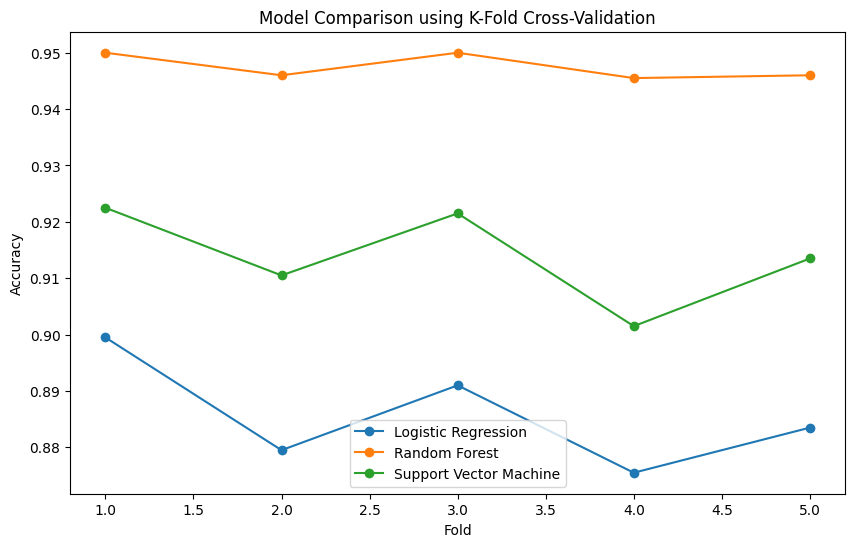

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
for model_name, scores in results.items():
  plt.plot(range(1, kf.n_splits+1), scores, marker='o', label=model_name)
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('Model Comparison using K-Fold Cross-Validation')
plt.legend()
plt.show()

In [ ]:
import numpy as np
def perceptron(x):
  weights = np.array([0.5,-0.5])
  bias = -0.2
  weighted_sum = np.dot(weights, x) + bias
  if weighted_sum > 0:
    return 1
  else:
    return 0
inputs = np.array([1,1])
print(perceptron(inputs))

0


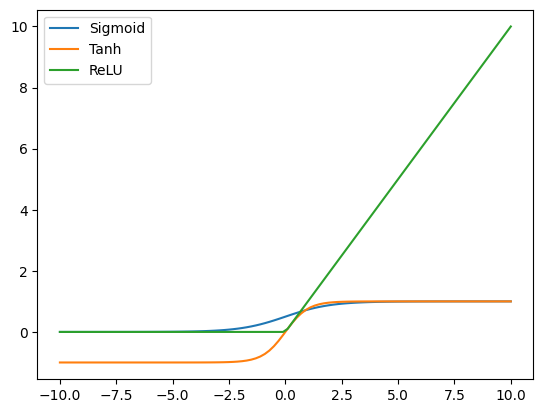

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
def sigmoid(x):
  return 1 / (1 + np.exp(-x))
def tanh(x):
  return np.tanh(x)
def relu(x):
  return np.maximum(0, x)
x = np.linspace(-10, 10, 100)
plt.plot(x, sigmoid(x), label='Sigmoid')
plt.plot(x, tanh(x), label='Tanh')
plt.plot(x, relu(x), label='ReLU')
plt.legend()
plt.show()


In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x_train = x_train/255.0 #Standardization
x_test = x_test/255.0
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
model = Sequential([Flatten(input_shape = (28, 28)),
                    Dense(128, activation = 'relu'),
                    Dense(64, activation = 'relu'),
                    Dense(10, activation = 'softmax')])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer= 'adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history = model.fit(x_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9712 - loss: 0.0911 - val_accuracy: 0.9712 - val_loss: 0.1004
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9787 - loss: 0.0673 - val_accuracy: 0.9662 - val_loss: 0.1190
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9858 - loss: 0.0461 - val_accuracy: 0.9724 - val_loss: 0.0962
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9884 - loss: 0.0362 - val_accuracy: 0.9728 - val_loss: 0.0984
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9903 - loss: 0.0285 - val_accuracy: 0.9738 - val_loss: 0.0981
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9921 - loss: 0.0243 - val_accuracy: 0.9705 - val_loss: 0.1183
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9924 - loss: 0.0225 - val_accuracy: 0.9732 - val_loss: 0.1096
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9946 - loss: 0.0166 - 

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9750 - loss: 0.1103
Test Accuracy: 0.9783999919891357


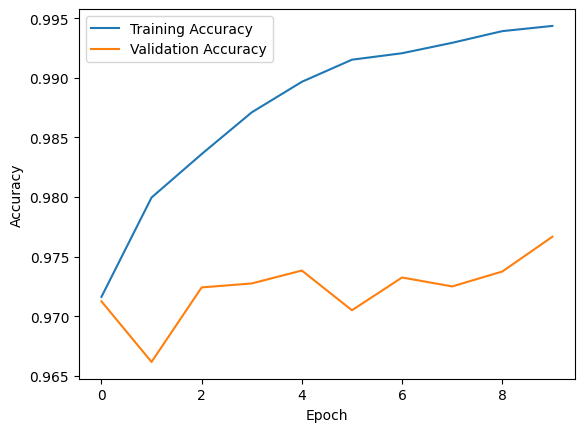

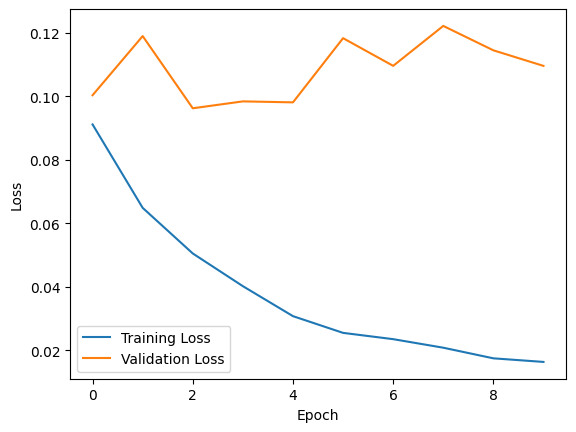

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
import numpy as np
image = np.array([ [1,2,3,0,1], [4,5,6,1,0], [7,8,9,0,1], [0,1,2,4,5], [1,2,3,4,5]])
filter = np.array([[1,0,-1],[1,0,-1],[1,0,-1]])
filter_size = filter.shape[0]
result = np.zeros((image.shape[0] - filter_size + 1, image.shape[1] - filter_size + 1))
for i in range(result.shape[0]):
  for j in range(result.shape[1]):
    result[i, j] = np.sum(image[i:i+filter_size, j:j+filter_size] * filter)
print("Original Name:", image)
print("Convolution Result: \n",result)

Original Name: [[1 2 3 0 1]
 [4 5 6 1 0]
 [7 8 9 0 1]
 [0 1 2 4 5]
 [1 2 3 4 5]]
Convolution Result: 
 [[-6. 14. 16.]
 [-6.  9. 11.]
 [-6.  3.  3.]]


In [ ]:
feature_map = np.array([[1,3,2,4], [5,6,1,2],[7,8,3,1],[2,3,4,5]])
pool_size = 2
result = np.zeros((feature_map.shape[0] // pool_size, feature_map.shape[1] // pool_size))
for i in range(result.shape[0]):
  for j in range(result.shape[1]):
    result[i, j] = np.max(feature_map[i*pool_size:(i+1)*pool_size, j*pool_size:(j+1)*pool_size])
print("Original Name:", feature_map)
print("Max Pooling Result: \n",result)

Original Name: [[1 3 2 4]
 [5 6 1 2]
 [7 8 3 1]
 [2 3 4 5]]
Max Pooling Result: 
 [[6. 4.]
 [8. 5.]]


In [2]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical


In [3]:
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()
train_images, test_images = train_images / 255.0, test_images / 255.0
train_labels = to_categorical(train_labels, 10)
test_labels = to_categorical(test_labels, 10)
print(f"Training data shape: {train_images.shape}")
print(f"Training labels shape: {train_labels.shape}")
print(f"Test data shape: {test_images.shape}")
print(f"Test labels shape: {test_labels.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 10)
Test data shape: (10000, 32, 32, 3)
Test labels shape: (10000, 10)


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([ Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),  MaxPooling2D((2, 2)),
                     Conv2D(64, (3, 3), activation='relu'), MaxPooling2D((2, 2)),
                    Flatten(), Dense(64, activation='relu'), Dropout(0.5), Dense(10, activation='softmax')])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_images, train_labels, epochs=10, validation_data=(test_images, test_labels))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.3012 - loss: 1.8751 - val_accuracy: 0.5275 - val_loss: 1.3292
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4878 - loss: 1.4242 - val_accuracy: 0.5730 - val_loss: 1.2245
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5436 - loss: 1.2897 - val_accuracy: 0.6166 - val_loss: 1.0994
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5717 - loss: 1.2054 - val_accuracy: 0.6271 - val_loss: 1.0817
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5898 - loss: 1.1594 - val_accuracy: 0.6538 - val_loss: 1.0001
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6114 - loss: 1.1022 - val_accuracy: 0.6530 - val_loss: 1.0236
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6180 - loss: 1.0761 - val_accuracy: 0.6616 - val_loss: 0.9806
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6313 - loss: 1.0388 -

In [7]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"Test Accuracy: {test_acc: 4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6837 - loss: 0.9209
Test Accuracy:  0.683200


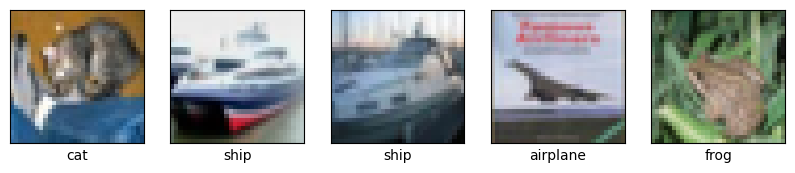

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 522ms/step
Image 1: Predicted - cat, True - cat

Image 2: Predicted - ship, True - ship

Image 3: Predicted - ship, True - ship

Image 4: Predicted - airplane, True - airplane

Image 5: Predicted - frog, True - frog



In [8]:
import numpy as np
import matplotlib.pyplot as plt
test_images_subset = test_images[:5]
test_labels_subset = test_labels[:5]
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
plt.figure(figsize=(10,2))
for i in range(len(test_images_subset)):
  plt.subplot(1, 5 , i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(test_images_subset[i], cmap=plt.cm.binary)
  plt.xlabel(class_names[np.argmax(test_labels_subset[i])])
plt.show()
predictions = model.predict(test_images_subset)
for i in range(len(test_images_subset)):
  predicted_label = np.argmax(predictions[i])
  true_label = np.argmax(test_labels_subset[i])
  print(f"Image {i+1}: Predicted - {class_names[predicted_label]}, True - {class_names[true_label]}")
  print()

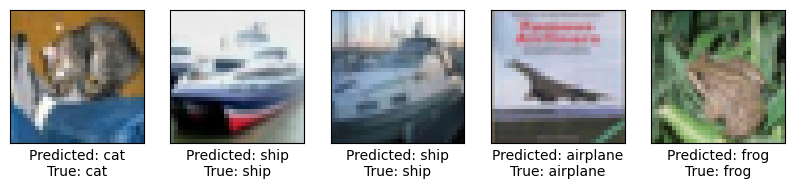

In [9]:
plt.figure(figsize=(10, 2))
for i in range(len(test_images_subset)):
    plt.subplot(1, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(test_images_subset[i], cmap=plt.cm.binary)
    predicted_label = np.argmax(predictions[i])
    true_label = np.argmax(test_labels_subset[i])
    plt.xlabel(f"Predicted: {class_names[predicted_label]}\nTrue: {class_names[true_label]}")
plt.show()


In [11]:
import numpy as np
class SimpleRNN:
  def __init__(self, input_size, hidden_size, output_size):
    self.hidden_size = hidden_size
    self.wx = np.random.randn(input_size, hidden_size)
    self.wh = np.random.randn(hidden_size, hidden_size)
    self.wy = np.random.randn(hidden_size, output_size)
    self.bh = np.zeros((1, hidden_size))
    self.by = np.zeros((1, output_size))
  def forward(self, inputs):
    h = np.zeros((inputs.shape[0], self.hidden_size))
    outputs = []
    for t in range(inputs.shape[1]):
      h = np.tanh(np.dot(inputs[:, t, :], self.wx) + np.dot(h, self.wh) + self.bh)
      y = np.dot(h, self.wy) + self.by
      outputs.append(y)
      return np.array(outputs), h
inputs = np.random.randn(5, 10, 8)
rnn = SimpleRNN(input_size=8, hidden_size=16, output_size=4)
outputs, h = rnn.forward(inputs)
print("Outputs Shape:", outputs.shape)
print("Hidden State Shape:", h)


Outputs Shape: (1, 5, 4)
Hidden State Shape: [[ 0.35194196 -0.96439398  0.91384135 -0.90570667 -0.2347706  -0.00934825
  -0.99657889 -0.47425273 -0.42214198 -0.99668051  0.18491977  0.99541705
   0.99140596 -0.98726037 -0.94006303 -0.97656831]
 [-0.99847016 -0.9897663   0.99773318  0.97608277  0.68023767 -0.83903618
  -0.99999999 -0.90943233  0.99764378 -0.99997487 -0.95924272  0.98445264
   0.99997599 -0.95316904 -0.97759335 -0.99998518]
 [ 0.60196216 -0.16424419  0.9999837   0.97757697  0.82594045  0.99707414
  -0.99999462  0.10532688  0.50830235  0.7800423  -0.99914467  0.99254636
  -0.08419838  0.45914677  0.53565754  0.99907103]
 [-0.9352398  -0.91733042  0.99855534  0.74915851  0.3649794   0.42670527
  -0.89908645 -0.9264033   0.99188433 -0.99255325 -0.99403984  0.99992232
   0.9377689   0.99638504 -0.06269013 -0.98839997]
 [-0.99932388 -0.95687177 -0.6145315  -0.89622641 -0.87833628 -0.99979701
   0.48833392 -0.97350116  0.99976235 -0.9999771   0.99723922  0.06221128
   0.999430